In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import sys
import warnings
sys.path.append("A2")
sys.path.append("preprocessing")
import regression_tree as rt
import random_forest as rf
import prediction_evaluation as eval
import grid_search
import parameter_eval
import preprocessing_food_wastage as pre_food_wastage
import preprocessing_college_ranking as pre_college_ranking
import preprocessing_popular_songs as pre_ppl_songs

pd.set_option("display.max_colwidth", None)

# Processing Datasets

Dataset Food Wastage
The full dataframe consists of 1782 rows, and 11 attributes
Rows containing NA values before preprocessing: 0


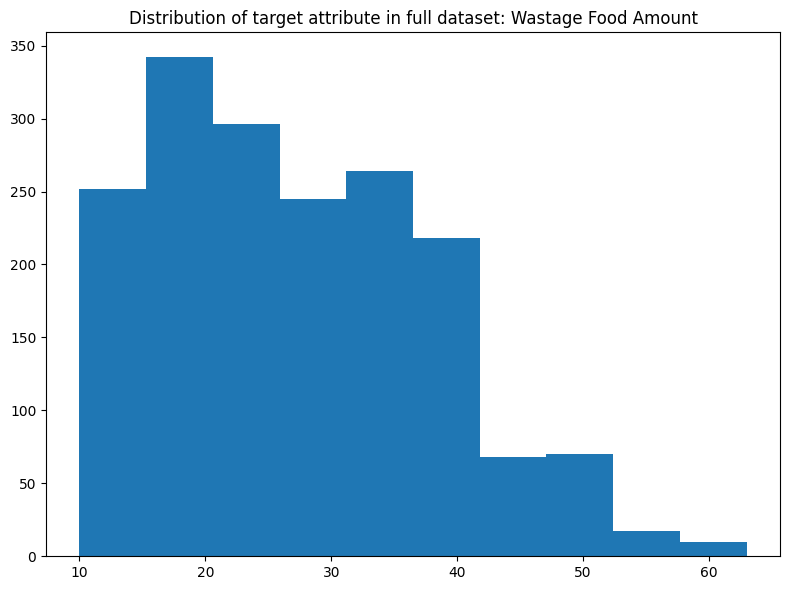

The train dataframe consists of 1188 rows, and 11 attributes


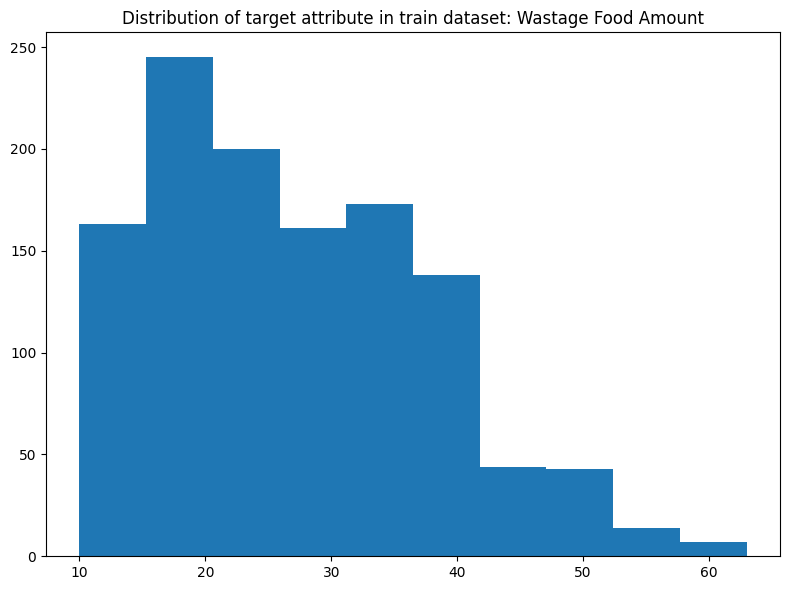

The test dataframe consists of 594 rows, and 11 attributes


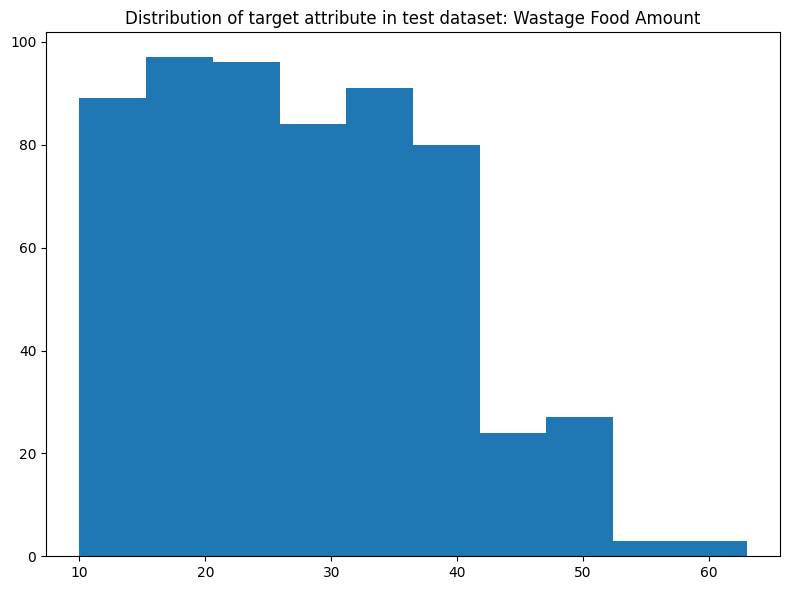

Dataset University Ranking
The full dataframe consists of 167 rows, and 41 attributes
Rows containing NA values before preprocessing: 160


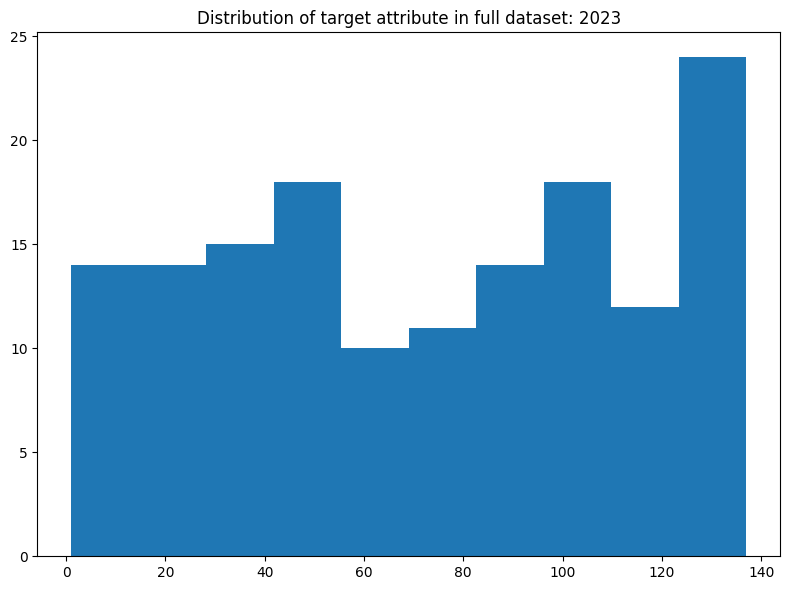

The train dataframe consists of 111 rows, and 41 attributes


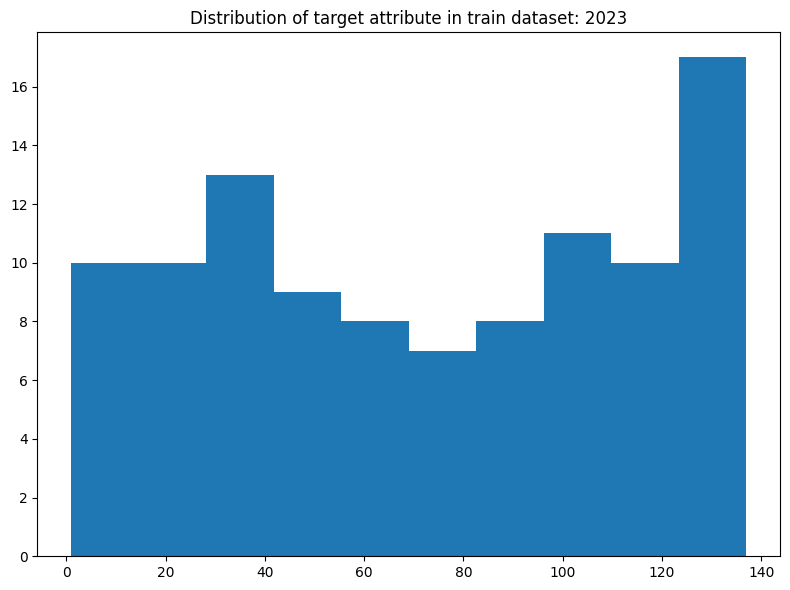

The test dataframe consists of 56 rows, and 41 attributes


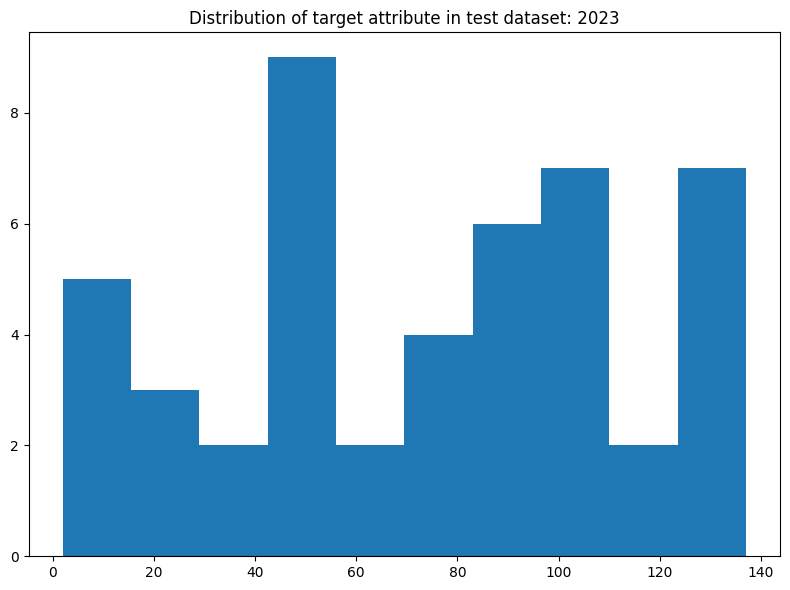

Null values count in the dataset 0
Categorical column "song_name" is at index:  0


In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)

food_waste_df_train, food_waste_df_test = pre_food_wastage.preprocessing_food_wastage()
college_rank_df_train, college_rank_df_test = pre_college_ranking.preprocessing_college_ranking()
popular_songs_features_train, popular_songs_features_test = pre_ppl_songs.preprocessing_polar_songs()

# Paramater Grid

In [20]:
param_grid = {
    'min_samples_split': range(4,16,2),
    'max_depth': range(1,10,2),
    'split_criterion': ['mse', 'sse']
}


param_grid_scikit = {
    'min_samples_split': range(4,16,2),
    'max_depth': range(1,10,2),
    'criterion': ['squared_error']
}


param_grid_rf = {
    'no_of_estimators': range(10,100,20),
    'split_criterion': ['sse', 'mse'],
    'max_depth': range(1,3,1),
    'min_samples_split': range(5,7,1),
    'max_features_criterion': ['sqrt', 'log2']
}

param_grid_rf_scikit = {
    'n_estimators': range(10,100,20),
    'criterion': ['squared_error'],
    'max_depth': range(1,3,1),
    'min_samples_split': range(5,7,1),
    'max_features': ['sqrt', 'log2']
}


# Regression Trees

## Food Waste

### Our Implementation

In [134]:
best_tree_food_waste, train_results_food_waste = grid_search.grid_search_cv2(food_waste_df_train, "wastage_food_amount", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_food_waste.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  7.7min finished


,runtime,mean_rmse,mean_mae,Parameters
0,43.661565,3.260844,2.120995,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
1,70.217996,3.542926,2.129355,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
2,79.892052,3.723714,2.497201,"{'min_samples_split': 8, 'max_depth': 7, 'split_criterion': 'sse'}"
3,61.577134,3.746507,2.279135,"{'min_samples_split': 6, 'max_depth': 9, 'split_criterion': 'sse'}"
4,104.392896,3.756801,2.369341,"{'min_samples_split': 8, 'max_depth': 9, 'split_criterion': 'sse'}"
5,50.396700,3.826036,2.494022,"{'min_samples_split': 6, 'max_depth': 7, 'split_criterion': 'sse'}"


### Scikitlearn Implementation

In [219]:
train_results_food_waste_scikit, best_tree_scikit_food_waste = grid_search.grid_search_scikit(food_waste_df_train, "wastage_food_amount", param_grid_scikit)
train_results_food_waste_scikit.loc[:5,]


Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=9, min_samples_split=14, random_state=1)
Time(s):  0.8795177999418229


,runtime,mean_rmse,mean_mae,Parameters
0,0.879518,3.202585,1.939226,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 14}"
1,0.879518,3.203612,1.914761,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 12}"
2,0.879518,3.213652,1.889940,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 10}"
3,0.879518,3.244165,1.879883,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,0.879518,3.286388,2.099310,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 6}"
5,0.879518,3.292443,2.100718,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 4}"


### Predictions on Test Set

In [236]:
food_waste_predictions_on_test_reg_tree = rt.predict_from_tree(best_tree_food_waste, food_waste_df_test)
food_waste_rmse_on_test_reg_tree, food_waste_mae_on_test_reg_tree = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_on_test_reg_tree)

food_waste_predictions_on_test_reg_tree_scikit = best_tree_scikit_food_waste.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_on_test_reg_tree_scikit, food_waste_mae_on_test_reg_tree_scikit = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_on_test_reg_tree_scikit)

print(f"Food waste score on test set using our own implementation. RMSE: {food_waste_rmse_on_test_reg_tree}, MAE: {food_waste_mae_on_test_reg_tree}")
print(f"Food waste score on test set using Scikit implementation. RMSE: {food_waste_rmse_on_test_reg_tree_scikit}, MAE: {food_waste_mae_on_test_reg_tree_scikit}")

Food waste score on test set using our own implementation. RMSE: 3.050349435526631, MAE: 1.9483544141466853
Food waste score on test set using Scikit implementation. RMSE: 3.1985216148270506, MAE: 1.8731796309690236


## College Rank

### Our Implementation

In [186]:
best_tree_college_rank, train_results_college_rank = grid_search.grid_search_cv2(college_rank_df_train, "2023", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_college_rank.loc[:5,]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   33.6s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  1.7min finished


,runtime,mean_rmse,mean_mae,Parameters
0,4.998084,9.178802,7.429202,"{'min_samples_split': 4, 'max_depth': 3, 'split_criterion': 'sse'}"
1,13.813458,9.316178,6.941028,"{'min_samples_split': 4, 'max_depth': 5, 'split_criterion': 'sse'}"
2,7.833440,9.704047,8.069895,"{'min_samples_split': 6, 'max_depth': 5, 'split_criterion': 'sse'}"
3,4.944218,9.866576,8.159236,"{'min_samples_split': 4, 'max_depth': 3, 'split_criterion': 'mse'}"
4,19.303758,10.001734,8.033945,"{'min_samples_split': 4, 'max_depth': 9, 'split_criterion': 'sse'}"
5,5.742125,10.119735,8.226652,"{'min_samples_split': 8, 'max_depth': 5, 'split_criterion': 'sse'}"


### Scikit-learn Implementation

In [217]:
train_results_college_rank_scikit, best_tree_scikit_college_rank = grid_search.grid_search_scikit(college_rank_df_train, "2023", param_grid_scikit)
train_results_college_rank_scikit.loc[:5,]


Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=5, min_samples_split=8, random_state=1)
Time(s):  0.7129336999496445


,runtime,mean_rmse,mean_mae,Parameters
0,0.712934,9.962908,7.933744,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 8}"
1,0.712934,10.119857,8.261271,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 12}"
2,0.712934,10.159822,8.173889,"{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}"
3,0.712934,10.237771,8.173559,"{'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 8}"
4,0.712934,10.254054,8.169620,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8}"
5,0.712934,10.329612,8.328360,"{'criterion': 'squared_error', 'max_depth': 3, 'min_samples_split': 10}"


### Predictions on test set

In [251]:
college_rank_predictions_reg_tree = rt.predict_from_tree(best_tree_college_rank, college_rank_df_test)
college_rank_rmse_on_test_reg_tree, college_rank_mae_on_test_reg_tree = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_reg_tree)

college_rank_predictions_reg_tree_scikit = best_tree_scikit_college_rank.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_on_test_reg_tree_scikit, college_rank_mae_on_test_reg_tree_scikit = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_reg_tree_scikit)

print(f"College Rank scores on test set using our implementation. RMSE: {college_rank_rmse_on_test_reg_tree}, MAE: {college_rank_mae_on_test_reg_tree}")
print(f"College Rank scores on test set using Scikit implementation. RMSE: {college_rank_rmse_on_test_reg_tree_scikit}, MAE: {college_rank_mae_on_test_reg_tree_scikit}")


College Rank scores on test set using our implementation. RMSE: 9.09345051351018, MAE: 7.23078231292517
College Rank scores on test set using Scikit implementation. RMSE: 10.103077791391781, MAE: 8.038446969696968


## Popular Songs

### Our Implementation

In [ ]:
best_tree_popular_songs, train_results_popular_songs = grid_search.grid_search_cv2(popular_songs_features_train, "song_popularity", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_popular_songs

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done  58 out of  60 | elapsed: 10.3min remaining:   21.3s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed: 10.6min finished


,runtime,mean_rmse,mean_mae,Parameters
0,101.825289,21.136044,16.758377,"{'min_samples_split': 6, 'max_depth': 7, 'split_criterion': 'sse'}"
1,94.972177,21.154821,16.800609,"{'min_samples_split': 14, 'max_depth': 7, 'split_criterion': 'sse'}"
2,124.470681,21.158103,16.772265,"{'min_samples_split': 12, 'max_depth': 7, 'split_criterion': 'sse'}"
3,106.221940,21.180077,16.805583,"{'min_samples_split': 4, 'max_depth': 7, 'split_criterion': 'sse'}"
4,119.138056,21.211852,16.837103,"{'min_samples_split': 10, 'max_depth': 7, 'split_criterion': 'sse'}"
5,155.790038,21.218091,16.721442,"{'min_samples_split': 12, 'max_depth': 9, 'split_criterion': 'sse'}"
6,89.603192,21.223502,16.904847,"{'min_samples_split': 12, 'max_depth': 5, 'split_criterion': 'sse'}"
7,84.689461,21.227343,16.877536,"{'min_samples_split': 14, 'max_depth': 5, 'split_criterion': 'sse'}"
8,145.697085,21.248849,16.766190,"{'min_samples_split': 8, 'max_depth': 9, 'split_criterion': 'sse'}"
9,75.729188,21.253179,16.888764,"{'min_samples_split': 6, 'max_depth': 5, 'split_criterion': 'sse'}"


### Scikitlearn Implementation

In [ ]:
sci_kit_results_popular_songs, best_tree_scikit_popular_songs = grid_search.grid_search_scikit(popular_songs_features_train, "song_popularity", param_grid_scikit)
sci_kit_results_popular_songs

Fitting 5 folds for each of 30 candidates, totalling 150 fits
DecisionTreeRegressor(max_depth=7, min_samples_split=6, random_state=1)
Time(s):  7.700856124982238


,runtime,mean_test_score,params
0,7.700856,21.262442,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 6}"
1,7.700856,21.270485,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 10}"
2,7.700856,21.272384,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 8}"
3,7.700856,21.273476,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 12}"
4,7.700856,21.278135,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 4}"
5,7.700856,21.280983,"{'criterion': 'squared_error', 'max_depth': 7, 'min_samples_split': 14}"


### Predictions on Test Set

In [ ]:
popular_songs_predictions_reg_tree = rt.predict_from_tree(best_tree_popular_songs, popular_songs_features_test)
popular_songs_rmse_reg_tree = eval.measure_predictions(popular_songs_features_test["song_popularity"], popular_songs_predictions_reg_tree)
print(f"College Rank RMSE score on test set using our implementation: {popular_songs_rmse_reg_tree}")

popular_songs_predictions_reg_tree_scikit = best_tree_scikit_popular_songs.predict(popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])
popular_songs_rmse_reg_tree_scikit = eval.rmse(popular_songs_features_test["song_popularity"], popular_songs_predictions_reg_tree_scikit)
print(f"College Rank RMSE score on test set using Scikit implementation: {popular_songs_rmse_reg_tree_scikit}")

College Rank RMSE score on test set using our implementation: (20.78015399960318, 16.49020398807111)
College Rank RMSE score on test set using Scikit implementation: 20.851354903578766


# Random Forest

For Random forest, we do not need to use CV, because then we loose the OOB data for each bootstrap. So we do OOB eval instead with the same grid.

## Food Waste

### Our Implementation

In [ ]:
best_forest_food_waste, train_results_rf_food_waste = grid_search.grid_search_oob2(food_waste_df_train, "wastage_food_amount", param_grid_rf)
train_results_rf_food_waste

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   35.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   54.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  74 out of  80 | elapsed:  2.0min remaining:   10.0s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  2.3min finished


,runtime,mean_rmse,mean_mae,Parameters
0,21.358103,6.512661,4.939527,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 70, 'max_features_criterion': 'log2'}"
1,15.331379,6.649088,5.008054,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 50, 'max_features_criterion': 'log2'}"
2,30.949997,6.791080,5.259297,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 90, 'max_features_criterion': 'log2'}"
3,9.799017,6.859480,5.352151,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 30, 'max_features_criterion': 'log2'}"
4,10.429180,7.062701,5.476291,"{'min_samples_split': 5, 'max_depth': 1, 'split_criterion': 'sse', 'no_of_estimators': 50, 'max_features_criterion': 'log2'}"
5,28.082053,7.070891,5.463970,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 90, 'max_features_criterion': 'sqrt'}"


### Scikit Implementation

In [21]:
sci_kit_results_food_waste_rf, best_forest_scikit_food_waste_rf = grid_search.grid_search_oob_scikit(food_waste_df_train, "wastage_food_amount", param_grid_rf_scikit)
sci_kit_results_food_waste_rf.loc[:5,]

Running combo: 1 out of: 40
Running combo: 2 out of: 40
Running combo: 3 out of: 40
Running combo: 4 out of: 40
Running combo: 5 out of: 40
Running combo: 6 out of: 40
Running combo: 7 out of: 40
Running combo: 8 out of: 40
Running combo: 9 out of: 40


/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartikarya/Library/CloudStorage/GoogleDrive-kartik.cs4030@rla.du.ac.in/My Drive/TU/S3/ML/Machine_learning_WS_2025/kml25/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/kartik

Running combo: 10 out of: 40
Running combo: 11 out of: 40
Running combo: 12 out of: 40
Running combo: 13 out of: 40
Running combo: 14 out of: 40
Running combo: 15 out of: 40
Running combo: 16 out of: 40
Running combo: 17 out of: 40
Running combo: 18 out of: 40
Running combo: 19 out of: 40
Running combo: 20 out of: 40
Running combo: 21 out of: 40
Running combo: 22 out of: 40
Running combo: 23 out of: 40
Running combo: 24 out of: 40
Running combo: 25 out of: 40
Running combo: 26 out of: 40
Running combo: 27 out of: 40
Running combo: 28 out of: 40
Running combo: 29 out of: 40
Running combo: 30 out of: 40
Running combo: 31 out of: 40
Running combo: 32 out of: 40
Running combo: 33 out of: 40
Running combo: 34 out of: 40
Running combo: 35 out of: 40
Running combo: 36 out of: 40
Running combo: 37 out of: 40
Running combo: 38 out of: 40
Running combo: 39 out of: 40
Running combo: 40 out of: 40


,runtime,mean_rmse,mean_mse,Parameters
0,0.072692,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'log2'}"
1,0.076917,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'log2'}"
2,0.073942,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
3,0.071984,7.397688,54.725791,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
4,0.025913,7.441144,55.370620,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'log2'}"
5,0.028206,7.441144,55.370620,"{'n_estimators': 30, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"


### Prediction on Test set

In [ ]:
# Our Implementation
food_waste_predictions_rf = rf.predict_from_forest(food_waste_df_test, best_forest_food_waste)
food_waste_rmse_rf = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_rf, "rmse")
print(f"RMSE score on test set using our implementation: {food_waste_rmse_rf}")


# scikit-learn
food_waste_predictions_rf_scikit = best_forest_scikit_food_waste_rf.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_rf_scikit = eval.rmse(food_waste_df_test["wastage_food_amount"], food_waste_predictions_rf_scikit)
print(f"Food waste RMSE score on test set using Scikit implementation: {food_waste_rmse_rf_scikit}")

## College Rank

### Our Implementation

In [23]:
best_forest_college_rank, train_results_rf_college_rank = grid_search.grid_search_oob2(college_rank_df_train, "2023", param_grid_rf)
train_results_rf_college_rank

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  74 out of  80 | elapsed:   22.6s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:   25.9s finished


,runtime,mean_rmse,mean_mae,Parameters
0,4.598543,14.422285,11.780126,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'log2'}"
1,4.915753,14.462594,11.275129,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"
2,0.711777,14.704111,11.921930,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"
3,2.647062,15.000870,12.094517,"{'no_of_estimators': 50, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
4,4.622990,15.089354,11.724692,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'log2'}"
5,5.402645,15.625307,12.395100,"{'no_of_estimators': 90, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"


### Scikit Implmentation

In [24]:
sci_kit_results_college_rank_rf, best_forest_scikit_college_rank_rf = grid_search.grid_search_oob_scikit(college_rank_df_train, "2023", param_grid_rf_scikit)
sci_kit_results_college_rank_rf.loc[:5,]

Running combo: 1 out of: 40
Running combo: 2 out of: 40
Running combo: 3 out of: 40
Running combo: 4 out of: 40
Running combo: 5 out of: 40
Running combo: 6 out of: 40
Running combo: 7 out of: 40
Running combo: 8 out of: 40
Running combo: 9 out of: 40
Running combo: 10 out of: 40
Running combo: 11 out of: 40
Running combo: 12 out of: 40
Running combo: 13 out of: 40
Running combo: 14 out of: 40
Running combo: 15 out of: 40
Running combo: 16 out of: 40
Running combo: 17 out of: 40
Running combo: 18 out of: 40
Running combo: 19 out of: 40
Running combo: 20 out of: 40
Running combo: 21 out of: 40
Running combo: 22 out of: 40
Running combo: 23 out of: 40
Running combo: 24 out of: 40
Running combo: 25 out of: 40
Running combo: 26 out of: 40
Running combo: 27 out of: 40
Running combo: 28 out of: 40
Running combo: 29 out of: 40
Running combo: 30 out of: 40
Running combo: 31 out of: 40
Running combo: 32 out of: 40
Running combo: 33 out of: 40
Running combo: 34 out of: 40
Running combo: 35 out o

,runtime,mean_rmse,mean_mse,Parameters
0,0.008081,14.568734,212.248016,"{'n_estimators': 10, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
1,0.007561,14.568734,212.248016,"{'n_estimators': 10, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
2,0.052668,14.684640,215.638644,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
3,0.052645,14.684640,215.638644,"{'n_estimators': 70, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"
4,0.061227,14.716491,216.575107,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6, 'max_features': 'sqrt'}"
5,0.060139,14.716491,216.575107,"{'n_estimators': 90, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}"


### Predictions on Test Set

In [ ]:
# Our Implementation
college_rank_predictions_rf = rf.predict_from_forest(college_rank_df_test, best_forest_college_rank)
college_rank_rmse_rf = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_rf, "rmse")
print(f"RMSE score on test set using our implementation: {college_rank_rmse_rf}")


# scikit-learn
college_rank_predictions_rf_scikit = best_forest_scikit_college_rank_rf.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_rf_scikit = eval.rmse(college_rank_df_test["2023"], college_rank_predictions_rf_scikit)
print(f"Food waste RMSE score on test set using Scikit implementation: {college_rank_rmse_rf_scikit}")

## Popular Songs

### Our Implementation

In [25]:
best_forest_popular_songs, train_results_rf_popular_songs = grid_search.grid_search_oob2(popular_songs_features_train, "song_popularity", param_grid_rf)
train_results_rf_popular_songs

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   35.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   53.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed: 10.4min
[Parallel(n_jobs=-1)]: Done  74 out of  80 | elapsed: 17.2min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed: 19.4min finished


,runtime,mean_rmse,mean_mae,Parameters
0,25.831670,21.484066,17.093212,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'sqrt'}"
1,25.427614,21.521842,17.146084,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'log2'}"
2,178.956955,21.525536,17.121200,"{'no_of_estimators': 70, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
3,86.553789,21.531737,17.105459,"{'no_of_estimators': 30, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'log2'}"
4,87.335658,21.533892,17.121329,"{'no_of_estimators': 30, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 6, 'max_features_criterion': 'log2'}"
5,25.641996,21.539004,17.174158,"{'no_of_estimators': 10, 'split_criterion': 'sse', 'max_depth': 2, 'min_samples_split': 5, 'max_features_criterion': 'sqrt'}"


### Scikit Implementation

In [ ]:
sci_kit_results_popular_songs_rf, best_forest_scikit_popular_songs_rf = grid_search.grid_search_oob_scikit(popular_songs_features_train, "song_popularity", param_grid_rf_scikit)
sci_kit_results_popular_songs_rf.loc[:5,]

### Predictions on test set

In [ ]:
# Our Implementation
popular_songs_predictions_rf = rf.predict_from_forest(popular_songs_features_test, best_forest_popular_songs)
popular_songs_rmse_rf, popular_songs_mae_rf = eval.measure_predictions(popular_songs_features_test["song_popularity"], popular_songs_predictions_rf)
print(f"RMSE score on test set using our implementation: {college_rank_rmse_rf}")


# scikit-learn
popular_songs_predictions_rf_scikit = best_forest_scikit_popular_songs_rf.predict(popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])
popular_songs_rmse_rf_scikit, popular_songs_mae_rf_scikit = eval.measure_predictions(popular_songs_features_test["song_popularity"], popular_songs_predictions_rf_scikit)
print(f"Food waste RMSE score on test set using Scikit implementation: {popular_songs_rmse_rf_scikit}")

# KNN

## Food Waste

In [292]:
food_waste_knn_model, food_waste_knn_runtime = grid_search.knn(food_waste_df_train, "wastage_food_amount")
food_waste_predictions_on_test_knn_scikit = food_waste_knn_model.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_on_test_knn_scikit, food_waste_mae_on_test_knn_scikit = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_on_test_reg_tree_scikit)

print(f"Food waste score on test set using Scikit KNN implementation. RMSE: {food_waste_rmse_on_test_knn_scikit}, MAE: {food_waste_mae_on_test_knn_scikit}")


food_waste_knn_results = {
    'runtime': food_waste_knn_runtime,
    'test set rmse': food_waste_rmse_on_test_knn_scikit,
    'test set mae': food_waste_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "Food Wastage",
    'implementation': 'Scikit'
}


Food waste score on test set using Scikit KNN implementation. RMSE: 3.1985216148270506, MAE: 1.8731796309690236


## College Rank

In [293]:
college_rank_knn_model, college_rank_knn_runtime = grid_search.knn(college_rank_df_train, "2023")
college_rank_predictions_on_test_knn_scikit = college_rank_knn_model.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_on_test_knn_scikit, college_rank_mae_on_test_knn_scikit = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_on_test_knn_scikit)

print(f"University rank score on test set using Scikit KNN implementation. RMSE: {college_rank_rmse_on_test_knn_scikit}, MAE: {college_rank_mae_on_test_knn_scikit}")


college_rank_knn_results = {
    'runtime': college_rank_knn_runtime,
    'test set rmse': college_rank_rmse_on_test_knn_scikit,
    'test set mae': college_rank_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "University Rank",
    'implementation': 'Scikit'
}


University rank score on test set using Scikit KNN implementation. RMSE: 11.764808297873547, MAE: 8.589285714285714


## Popular Songs

In [10]:
popular_songs_knn_model, popular_songs_knn_runtime = grid_search.knn(popular_songs_features_train, "song_popularity")
popular_songs_predictions_on_test_knn_scikit = popular_songs_knn_model.predict(popular_songs_features_test.loc[:, popular_songs_features_test.columns != "song_popularity"])
popular_songs_rmse_on_test_knn_scikit, popular_songs_mae_on_test_knn_scikit = eval.measure_predictions(popular_songs_features_test["song_popularity"], popular_songs_predictions_on_test_knn_scikit)

print(f"Popular Songs score on test set using Scikit KNN implementation. RMSE: {popular_songs_rmse_on_test_knn_scikit}, MAE: {popular_songs_mae_on_test_knn_scikit}")


popular_songs_knn_results = {
    'runtime': popular_songs_knn_runtime,
    'test set rmse': popular_songs_rmse_on_test_knn_scikit,
    'test set mae': popular_songs_mae_on_test_knn_scikit,
    'algorithm': "KNN",
    'dataset': "Popular Songs",
    'implementation': 'Scikit'
}


Popular Songs score on test set using Scikit KNN implementation. RMSE: 32.06528065740422, MAE: 24.653074227460976


# Hyperparameter Sensitivity Evaluation

## Regression Tree

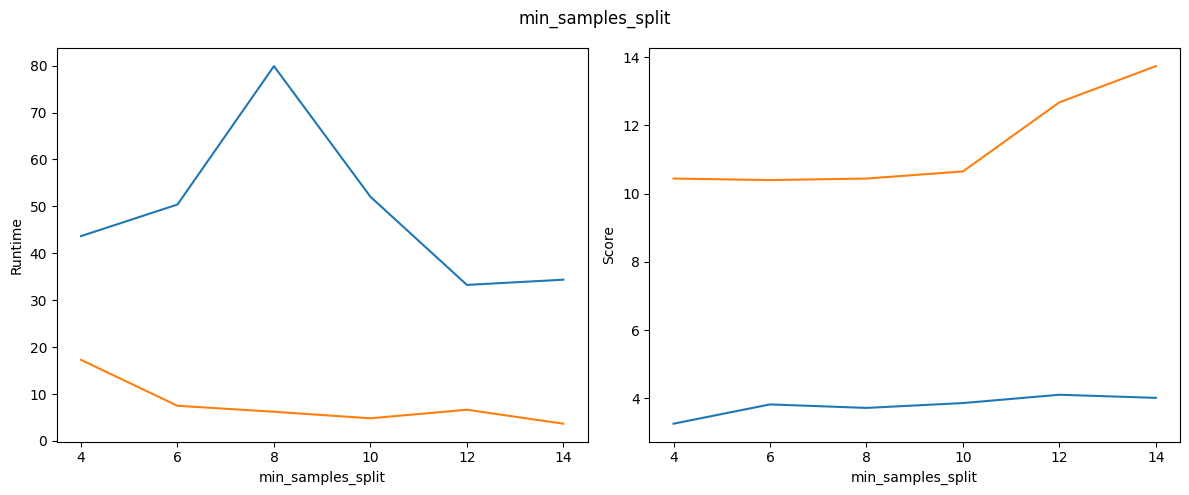

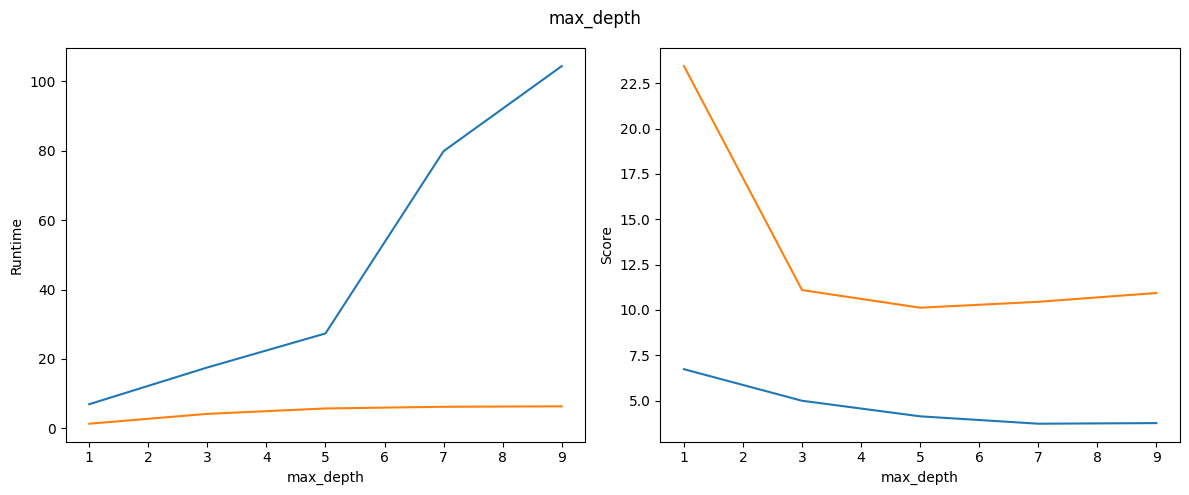

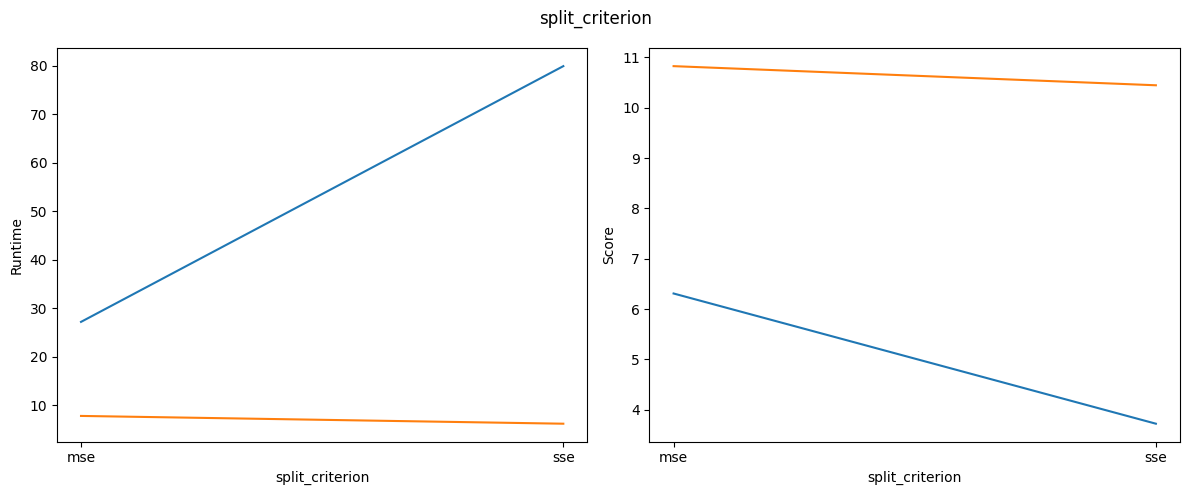

In [ ]:
eval_param = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse'
}

parameter_eval.plot_parameter(train_results_food_waste, train_results_college_rank, train_results_popular_songs, param_grid, eval_param)

## Random Forest

0    70
1    50
2    90
3    30
4    50
5    90
Name: no_of_estimators, dtype: int64


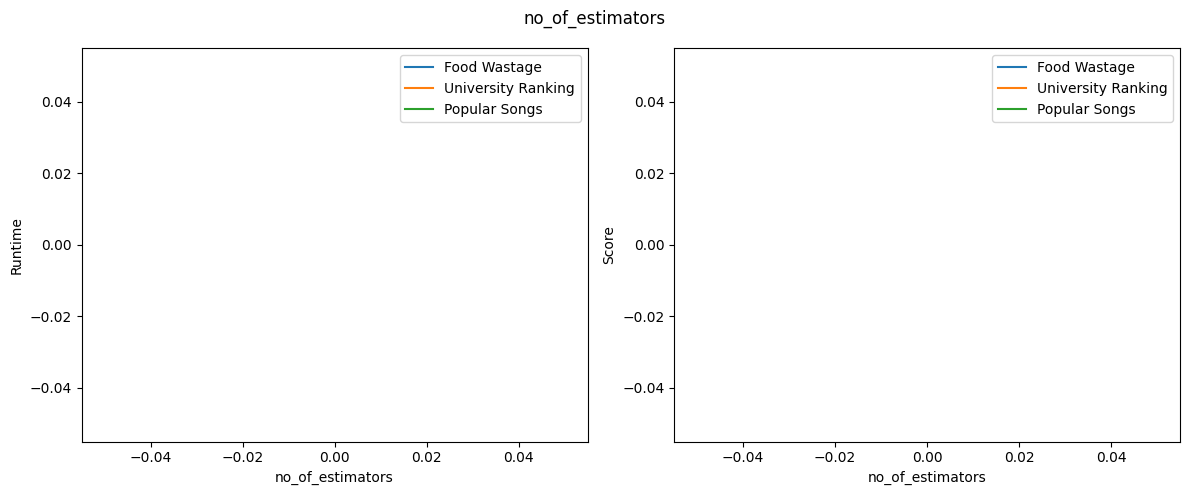

0    sse
1    sse
2    sse
3    sse
4    sse
5    sse
Name: split_criterion, dtype: object


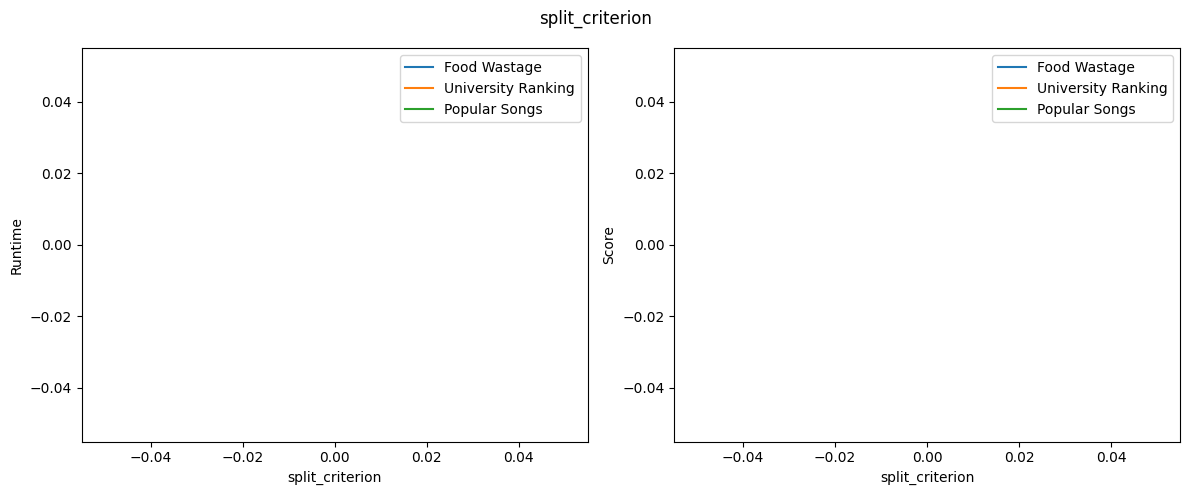

0    2
1    2
2    2
3    2
4    1
5    2
Name: max_depth, dtype: int64


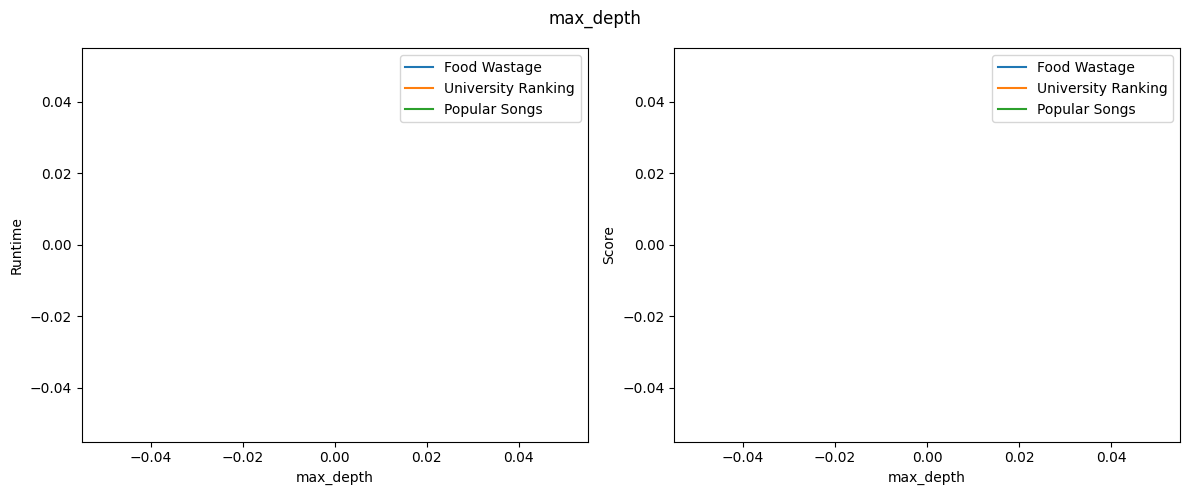

0    6
1    6
2    5
3    6
4    5
5    6
Name: min_samples_split, dtype: int64


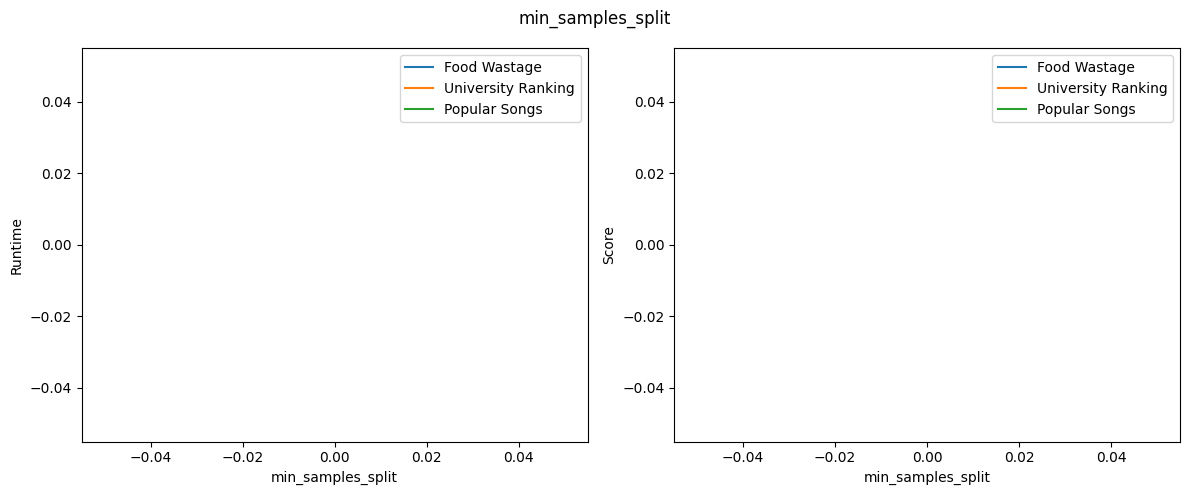

0    log2
1    log2
2    log2
3    log2
4    log2
5    sqrt
Name: max_features_criterion, dtype: object


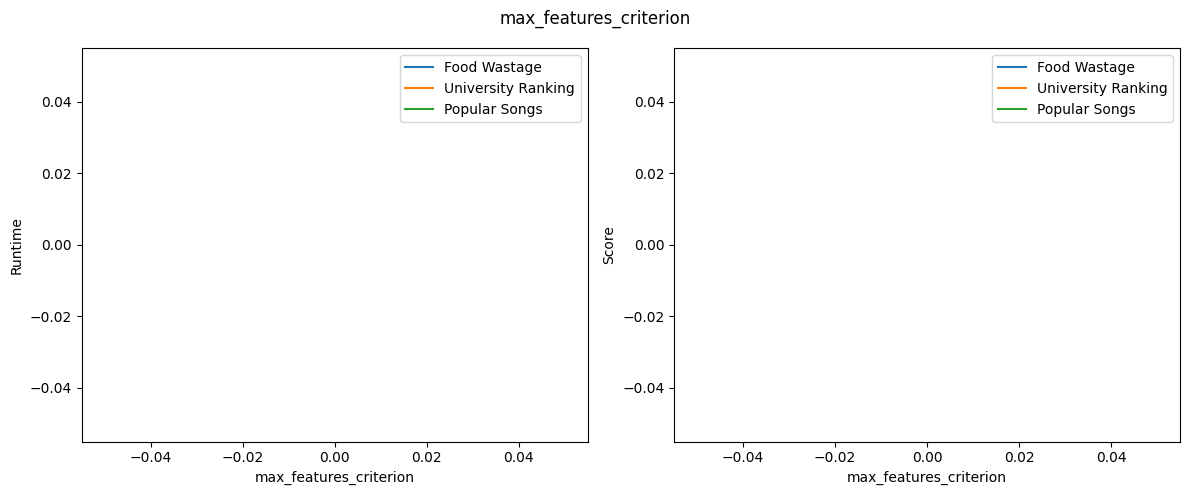

In [29]:
eval_param_rf = {
    'min_samples_split': 8,
    'max_depth': 7,
    'split_criterion': 'sse',
    'no_of_estimators': 50,
    'max_features_criterion': 'sqrt'
}

parameter_eval.plot_parameter(train_results_rf_food_waste, train_results_rf_college_rank, train_results_rf_popular_songs, param_grid_rf, eval_param_rf)

# Big Table

In [ ]:

all_results = pd.concat([
    train_results_food_waste.loc[[0]].assign(algorithm="Regression Tree", dataset="Food Wastage", implementation="Ours"),
    train_results_food_waste_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="Food Wastage", implementation="Scikit"),
    train_results_college_rank.loc[[0]].assign(algorithm="Regression Tree", dataset="University Rank", implementation="Ours"),
    train_results_college_rank_scikit.loc[[0]].assign( algorithm="Regression Tree", dataset="University Rank", implementation="Scikit"),
    #train_results_popular_songs.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Ours")
    #train_results_popular_songs_scikit.loc[[0]].assign(algorithm="Regression Tree", dataset="Popular Songs", implementation="Scikit"),
    
# add rf table here

]).reset_index(drop=True)
all_results = all_results.join(all_results['Parameters'].apply(pd.Series))

index_to_fix = ~all_results["criterion"].isna()
all_results.loc[index_to_fix, "split_criterion"] = all_results.loc[index_to_fix, "criterion"]

all_results = all_results.drop(["Parameters", "criterion"], axis=1)
all_results = all_results.rename(columns={'mean_rmse':'cross validated rmse', 'mean_mae': "cross validated mae"})


all_results = eval.big_table_formating(
    "Food Wastage", 
    all_results,
    food_waste_rmse_on_test_reg_tree,
    food_waste_mae_on_test_reg_tree,
    food_waste_rmse_on_test_reg_tree_scikit,
    food_waste_mae_on_test_reg_tree_scikit
)

all_results = eval.big_table_formating(
    "University Rank", 
    all_results,
    college_rank_rmse_on_test_reg_tree,
    college_rank_mae_on_test_reg_tree,
    college_rank_rmse_on_test_reg_tree_scikit,
    college_rank_mae_on_test_reg_tree_scikit
)

'''
all_results = eval.big_table_formating(
    "Popular Songs", 
    all_results,
    popular_songs_rmse_on_test_reg_tree,
    popular_songs_mae_on_test_reg_tree,
    popular_songs_rmse_on_test_reg_tree_scikit,
    popular_songs_mae_on_test_reg_tree_scikit
)
'''
#ADD RF TEST RESULTS

all_results = pd.concat([all_results, pd.DataFrame([food_waste_knn_results, college_rank_knn_results])], ignore_index=True)

all_results_reorderd = all_results[["runtime", "min_samples_split", "max_depth", "split_criterion", "cross validated rmse", "cross validated mae", "test set rmse", "test set mae", "algorithm", "dataset", "implementation"]]

all_results_reorderd

,runtime,min_samples_split,max_depth,split_criterion,cross validated rmse,cross validated mae,test set rmse,test set mae,algorithm,dataset,implementation
0,43.661565,4.0,7.0,sse,3.260844,2.120995,3.050349,1.948354,Regression Tree,Food Wastage,Ours
1,0.879518,14.0,9.0,squared_error,3.202585,1.939226,3.198522,1.873180,Regression Tree,Food Wastage,Scikit
2,7.659678,6.0,5.0,mse,9.899015,8.058231,9.093451,7.230782,Regression Tree,University Rank,Ours
3,1.516648,8.0,5.0,squared_error,9.962908,7.933744,10.103078,8.038447,Regression Tree,University Rank,Scikit
4,0.014968,NaN,NaN,NaN,NaN,NaN,3.198522,1.873180,KNN,Food Wastage,Scikit
5,0.011826,NaN,NaN,NaN,NaN,NaN,11.764808,8.589286,KNN,University Rank,Scikit
